# IMPORT

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, GridSearchCV, cross_val_predict
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.impute import KNNImputer
import warnings

warnings.filterwarnings('ignore')


# EDA

In [3]:
# Load data
df = pd.read_csv('../diabetes_frankurt_germany.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2000, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


In [4]:
# Cek missing values dan nilai 0
print("Missing values:")
print(df.isnull().sum())

# Total baris yang memiliki missing values
total_missing_rows = df.isnull().any(axis=1).sum()
print(f"\nTotal baris yang memiliki missing values: {total_missing_rows}")
print(f"Persentase baris dengan missing values: {(total_missing_rows/len(df)*100):.2f}%")

print("\nNilai 0 pada setiap kolom:")
zero_counts = {}
for col in df.columns:
    if col != 'Outcome':
        zero_count = (df[col] == 0).sum()
        zero_counts[col] = zero_count
        print(f"{col}: {zero_count}")

# Total baris yang memiliki minimal satu nilai 0 (selain Outcome)
features_with_zero = df.drop('Outcome', axis=1) == 0
total_zero_rows = features_with_zero.any(axis=1).sum()
print(f"\nTotal baris yang memiliki minimal satu nilai 0: {total_zero_rows}")
print(f"Persentase baris dengan nilai 0: {(total_zero_rows/len(df)*100):.2f}%")

# Detail kombinasi missing values
print(f"\nTotal sampel dalam dataset: {len(df)}")
print(f"Baris tanpa missing values: {len(df) - total_missing_rows}")
print(f"Baris tanpa nilai 0: {len(df) - total_zero_rows}")

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total baris yang memiliki missing values: 0
Persentase baris dengan missing values: 0.00%

Nilai 0 pada setiap kolom:
Pregnancies: 301
Glucose: 13
BloodPressure: 90
SkinThickness: 573
Insulin: 956
BMI: 28
DiabetesPedigreeFunction: 0
Age: 0

Total baris yang memiliki minimal satu nilai 0: 1124
Persentase baris dengan nilai 0: 56.20%

Total sampel dalam dataset: 2000
Baris tanpa missing values: 2000
Baris tanpa nilai 0: 876


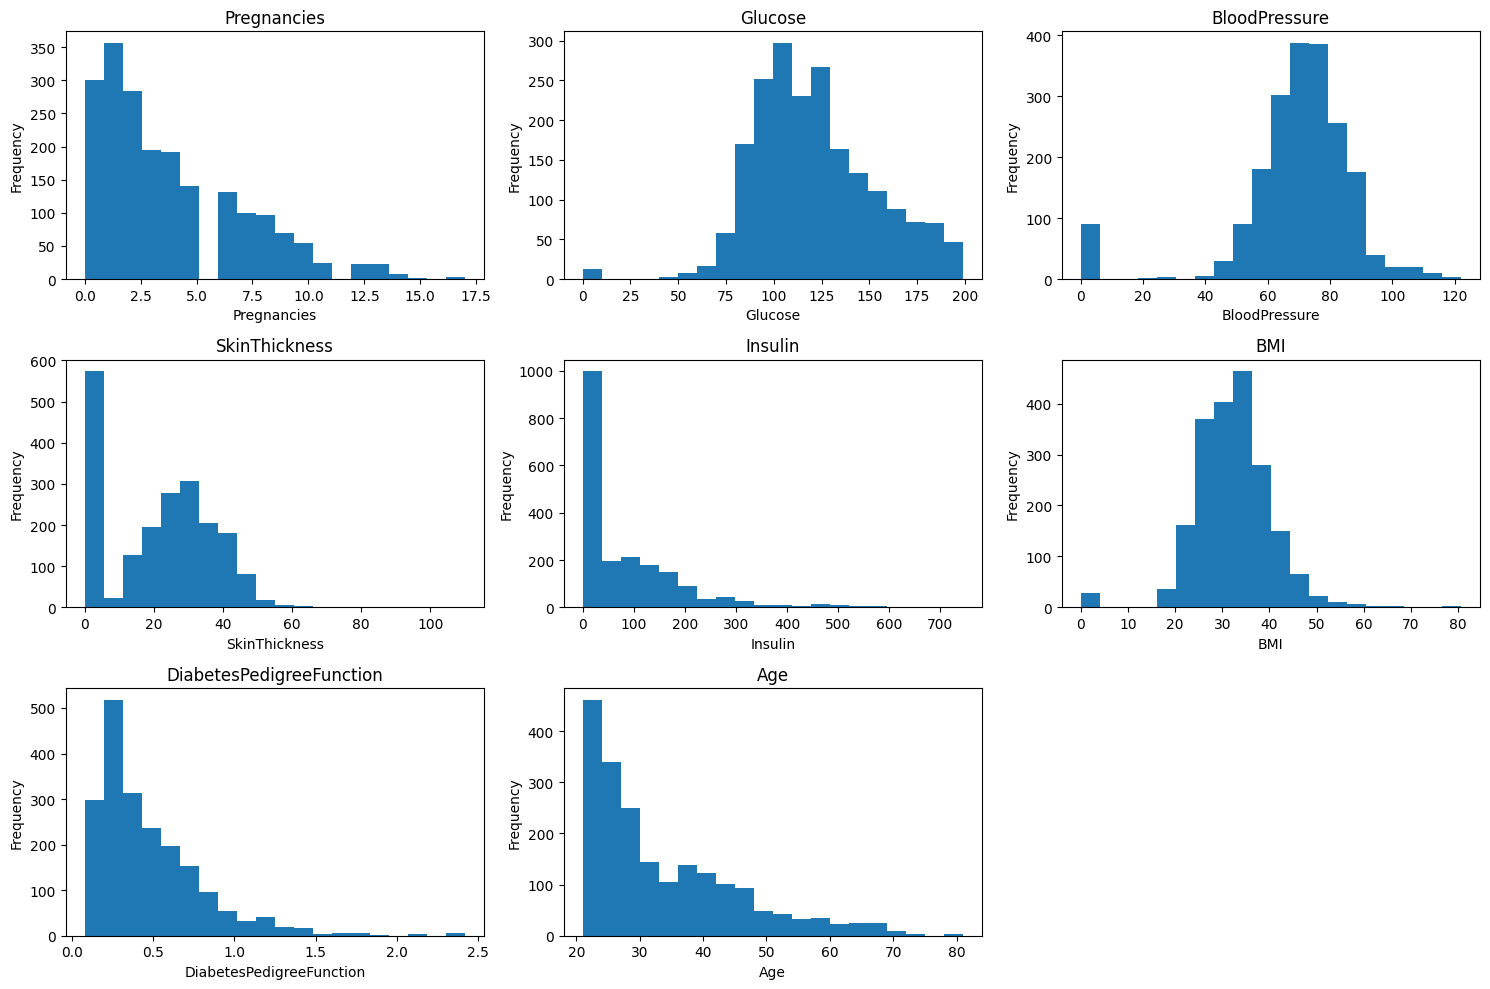

In [5]:
# Distribusi setiap fitur
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.columns):
    if col == 'Outcome':
        continue
    plt.subplot(3, 3, i+1)
    plt.hist(df[col], bins=20)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

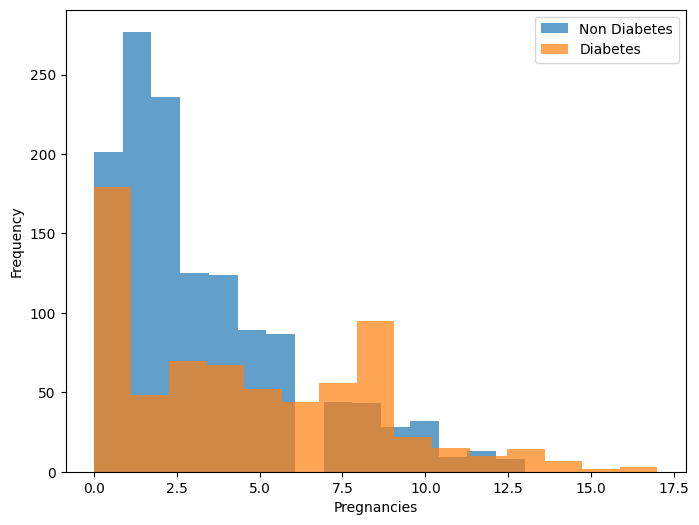

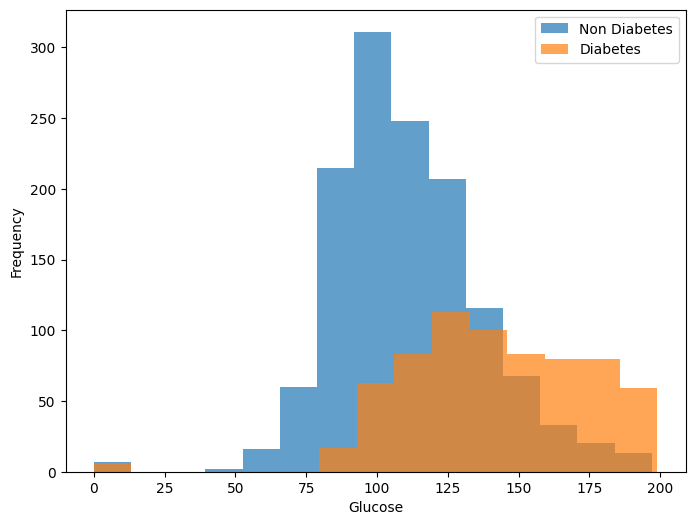

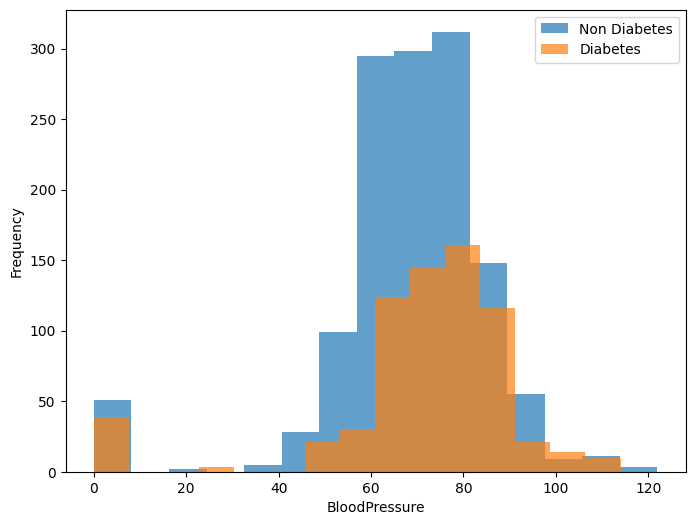

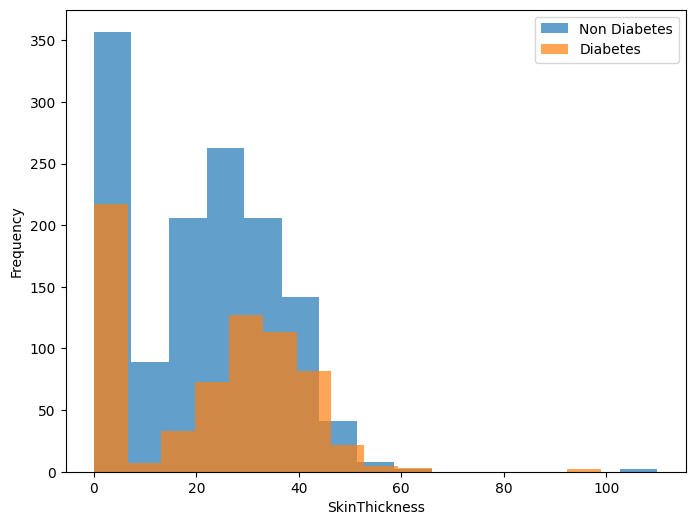

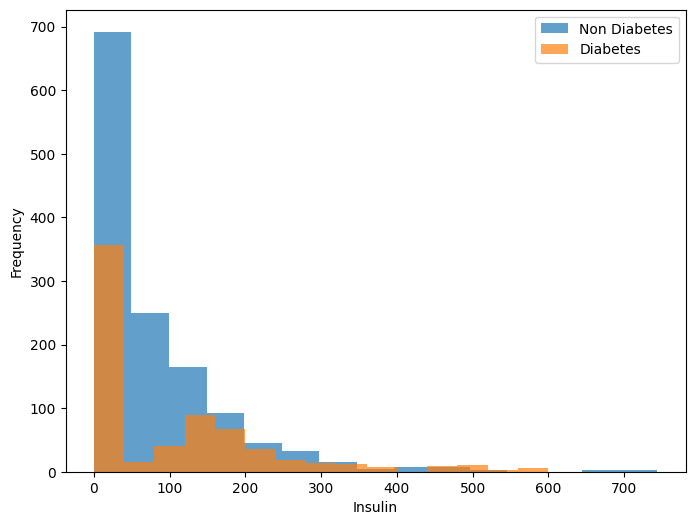

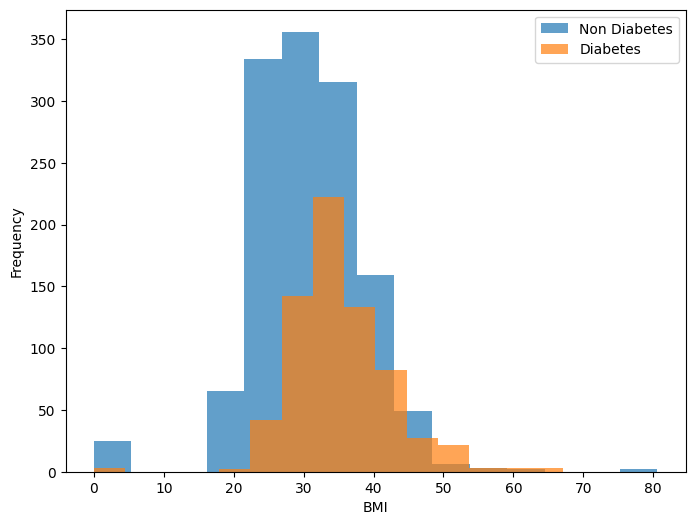

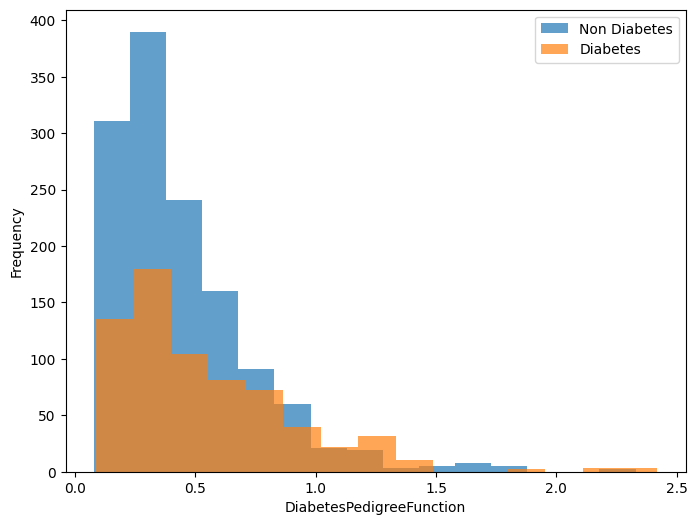

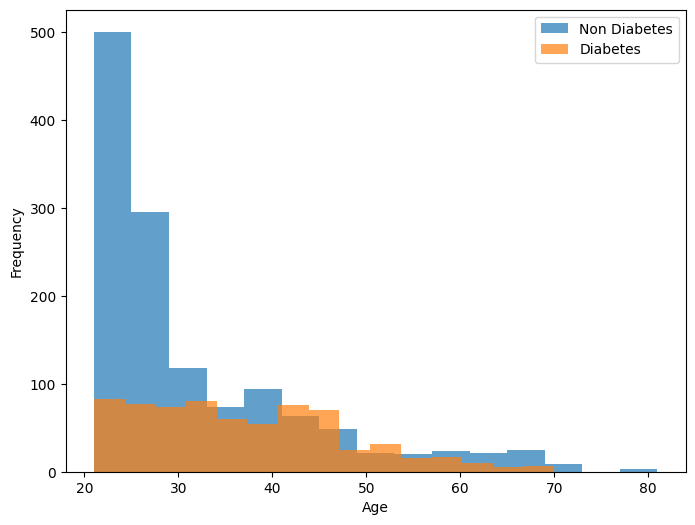

In [13]:
# Distribusi fitur terhadap target (Outcome) - satu per satu
features = df.columns[:-1]  # semua kecuali Outcome

for col in features:
    plt.figure(figsize=(8, 6))
    for outcome in [0, 1]:
        data = df[df['Outcome'] == outcome][col]
        label = 'Non Diabetes' if outcome == 0 else 'Diabetes'
        plt.hist(data, alpha=0.7, label=label, bins=15)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

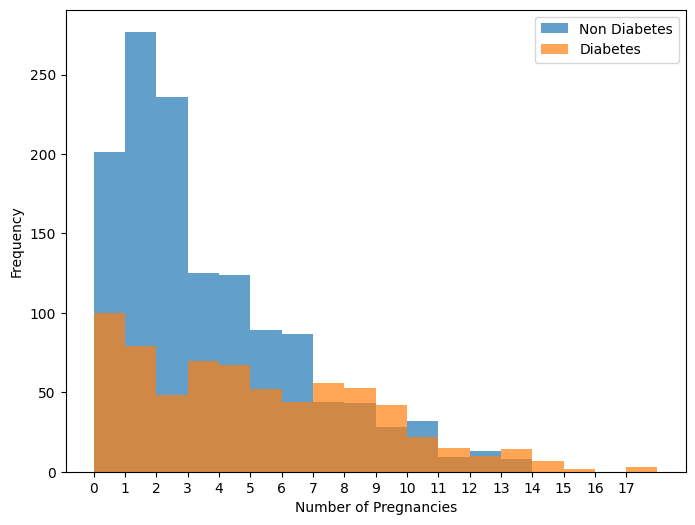

In [14]:
plt.figure(figsize=(8, 6))
for outcome in [0, 1]:
    data = df[df['Outcome'] == outcome]['Pregnancies']
    label = 'Non Diabetes' if outcome == 0 else 'Diabetes'
    plt.hist(data, alpha=0.7, label=label, bins=range(0, int(df['Pregnancies'].max()) + 2))
plt.xlabel('Number of Pregnancies')
plt.ylabel('Frequency')
plt.xticks(range(0, int(df['Pregnancies'].max()) + 1))
plt.legend()
plt.show()

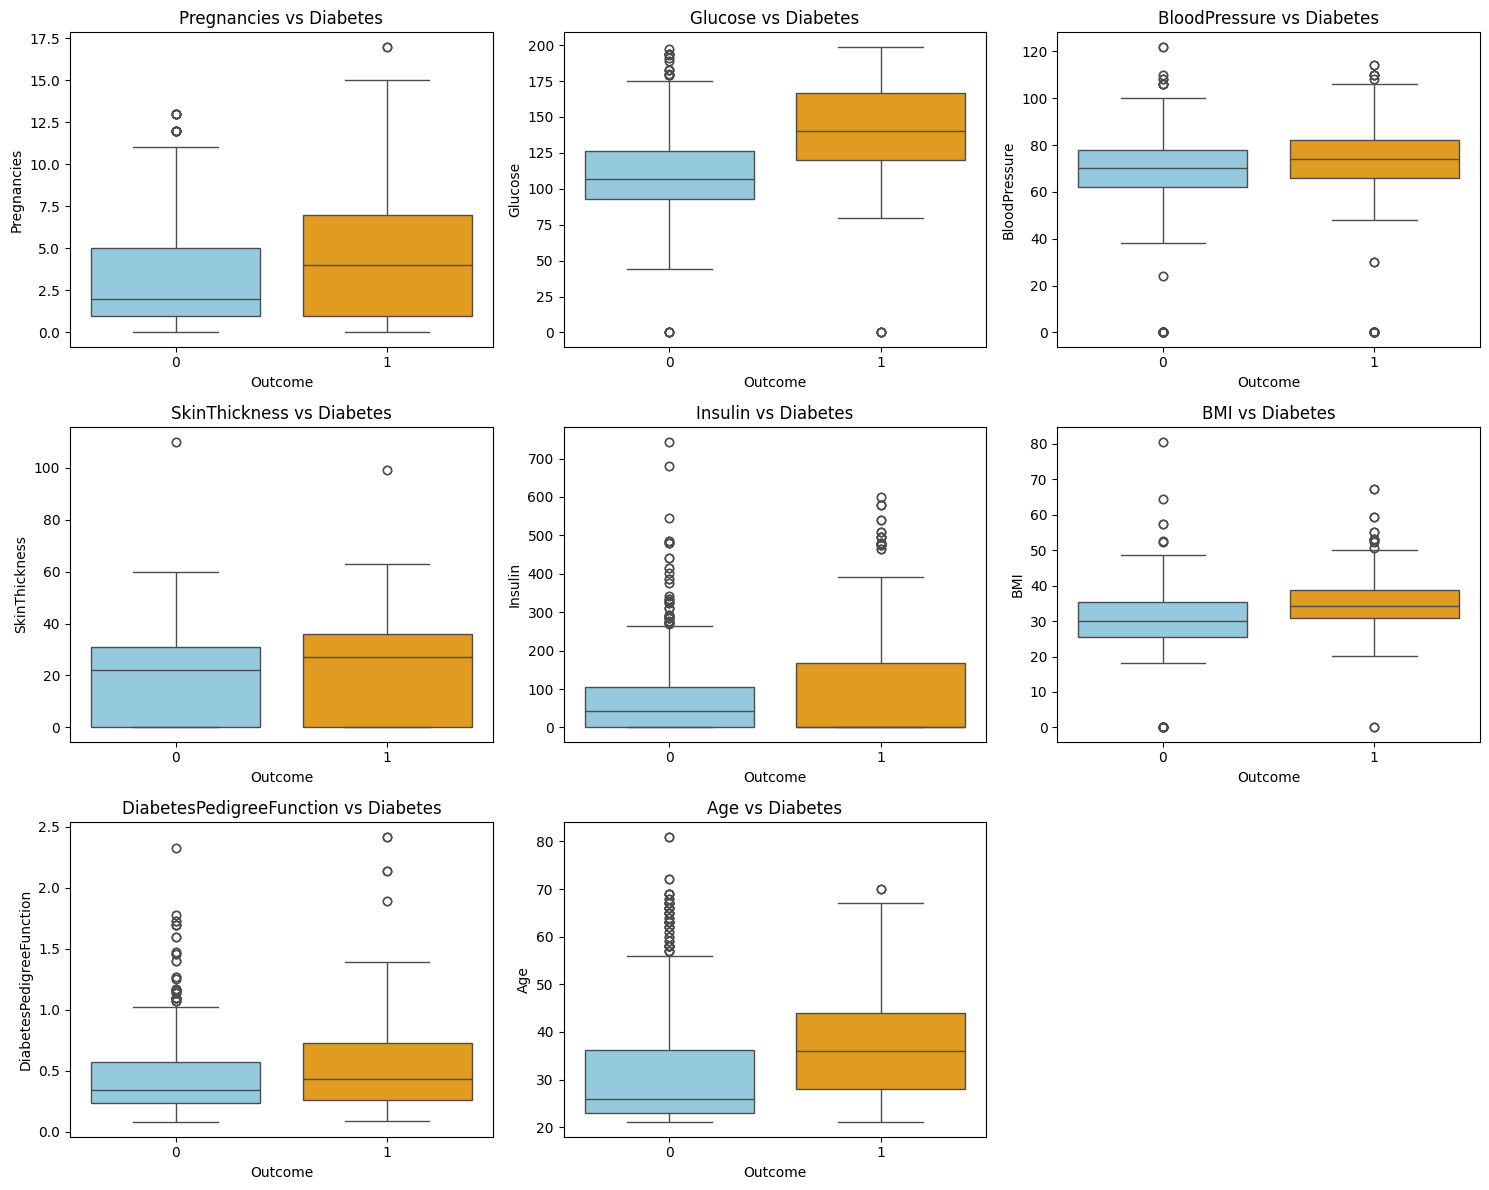

In [7]:
# Boxplot fitur terhadap target
plt.figure(figsize=(15, 12))
features = df.columns[:-1]  # semua kecuali Outcome
for i, col in enumerate(features):
    plt.subplot(3, 3, i+1)
    sns.boxplot(data=df, x='Outcome', y=col, hue='Outcome', palette=['skyblue', 'orange'], legend=False)
    plt.title(f'{col} vs Diabetes')
plt.tight_layout()
plt.show()

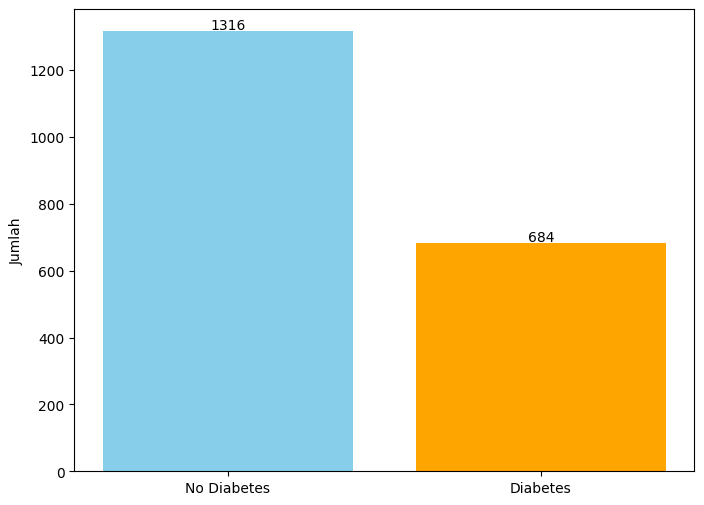

In [16]:
# Distribusi kelas pada target (Outcome)
plt.figure(figsize=(8, 6))
outcome_counts = df['Outcome'].value_counts()
plt.bar(outcome_counts.index, outcome_counts.values, color=['skyblue', 'orange'])
plt.ylabel('Jumlah')
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])  # Menambahkan baris ini
for i, v in enumerate(outcome_counts.values):
    plt.text(i, v + 5, str(v), ha='center')
plt.show()

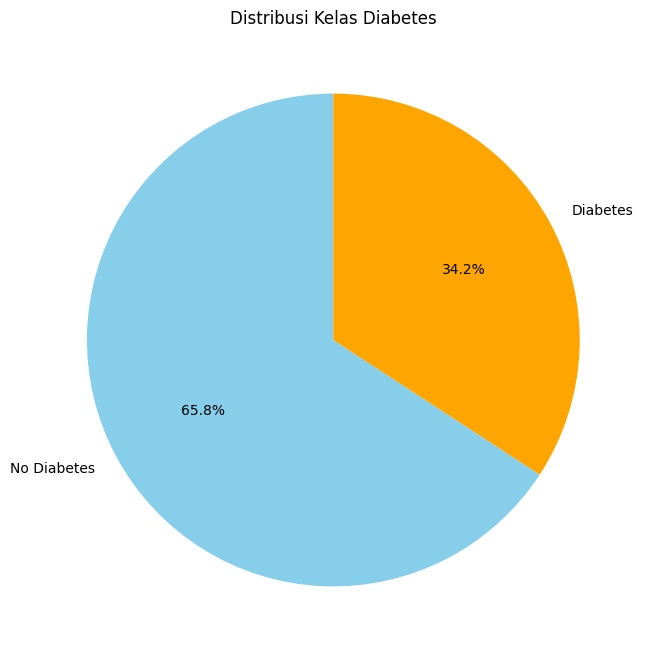

In [9]:
# Pie chart distribusi kelas
plt.figure(figsize=(8, 8))
outcome_counts = df['Outcome'].value_counts()
labels = ['No Diabetes', 'Diabetes']
colors = ['skyblue', 'orange']
plt.pie(outcome_counts.values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Distribusi Kelas Diabetes')
plt.show()

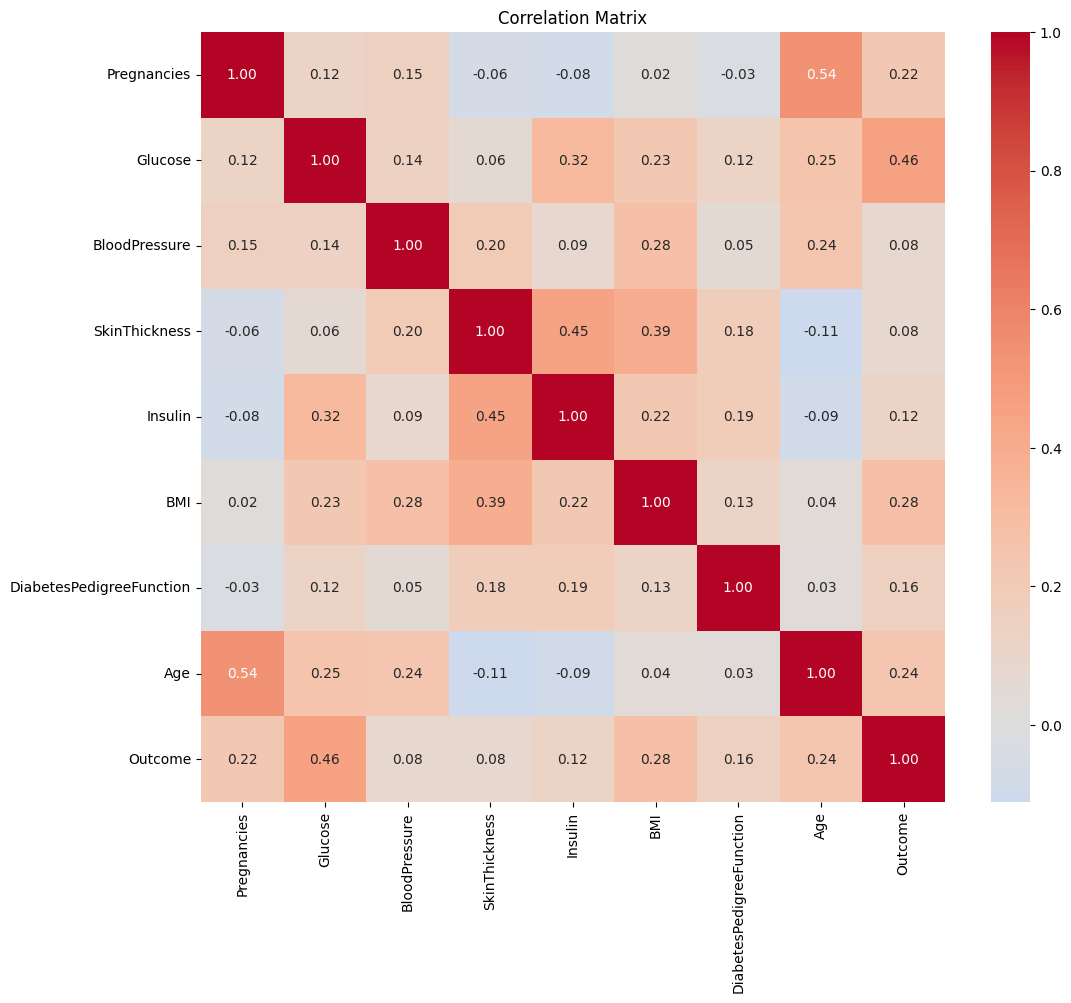

In [10]:
# Korelasi matriks
plt.figure(figsize=(12, 10))
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# PREPO

## IMPUTASI - KNN

In [167]:
colusmns_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_impute = df.copy()

In [168]:
for col in colusmns_to_impute:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count}")
for col in colusmns_to_impute:
    df_impute.loc[df_impute[col] == 0, col] = np.nan
df_impute.head()

Glucose: 13
BloodPressure: 90
SkinThickness: 573
Insulin: 956
BMI: 28


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138.0,62.0,35.0,NaN,33.6,0.127,47,1
1,0,84.0,82.0,31.0,125.0,38.2,0.233,23,0
2,0,145.0,NaN,NaN,NaN,44.2,0.630,31,1
3,0,135.0,68.0,42.0,250.0,42.3,0.365,24,1
4,1,139.0,62.0,41.0,480.0,40.7,0.536,21,0


In [169]:
# Pisahkan fitur dan target
X_for_imputation = df_impute.drop('Outcome', axis=1)
y_original = df_impute['Outcome']

In [170]:
knn_imputer = KNNImputer(n_neighbors=5)

In [171]:
X_imputed = knn_imputer.fit_transform(X_for_imputation)

In [172]:
df_final = pd.DataFrame(X_imputed, columns=X_for_imputation.columns)
df_final['Outcome'] = y_original.values

In [173]:
df_final = pd.DataFrame(X_imputed, columns=X_for_imputation.columns)
df_final['Outcome'] = y_original.values

In [174]:
df_final = pd.DataFrame(X_imputed, columns=X_for_imputation.columns)
df_final['Outcome'] = y_original.values

In [175]:
for col in colusmns_to_impute:
    zero_count = (df_final[col] == 0).sum()
    print(f"{col}: {zero_count}")

Glucose: 0
BloodPressure: 0
SkinThickness: 0
Insulin: 0
BMI: 0


In [176]:
df = df_final.copy()

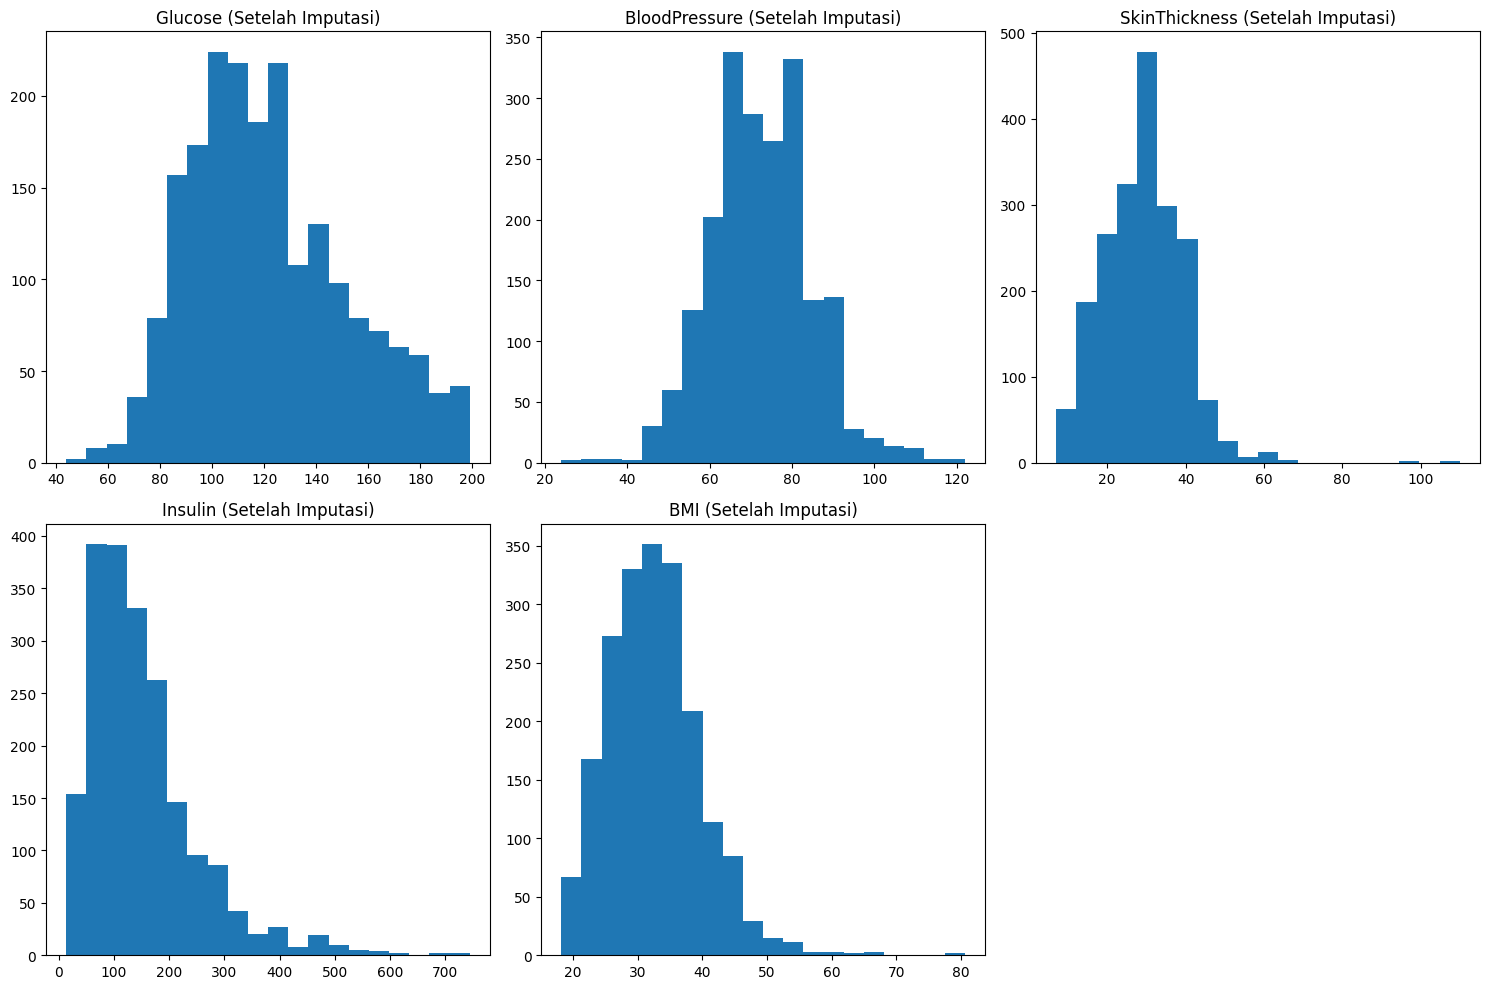

In [177]:
# Cek distribusi setelah imputasi
plt.figure(figsize=(15, 10))
plt.subplot(2, 3, 1)
plt.hist(df['Glucose'], bins=20)
plt.title('Glucose (Setelah Imputasi)')

plt.subplot(2, 3, 2)
plt.hist(df['BloodPressure'], bins=20)
plt.title('BloodPressure (Setelah Imputasi)')

plt.subplot(2, 3, 3)
plt.hist(df['SkinThickness'], bins=20)
plt.title('SkinThickness (Setelah Imputasi)')

plt.subplot(2, 3, 4)
plt.hist(df['Insulin'], bins=20)
plt.title('Insulin (Setelah Imputasi)')

plt.subplot(2, 3, 5)
plt.hist(df['BMI'], bins=20)
plt.title('BMI (Setelah Imputasi)')

plt.tight_layout()
plt.show()

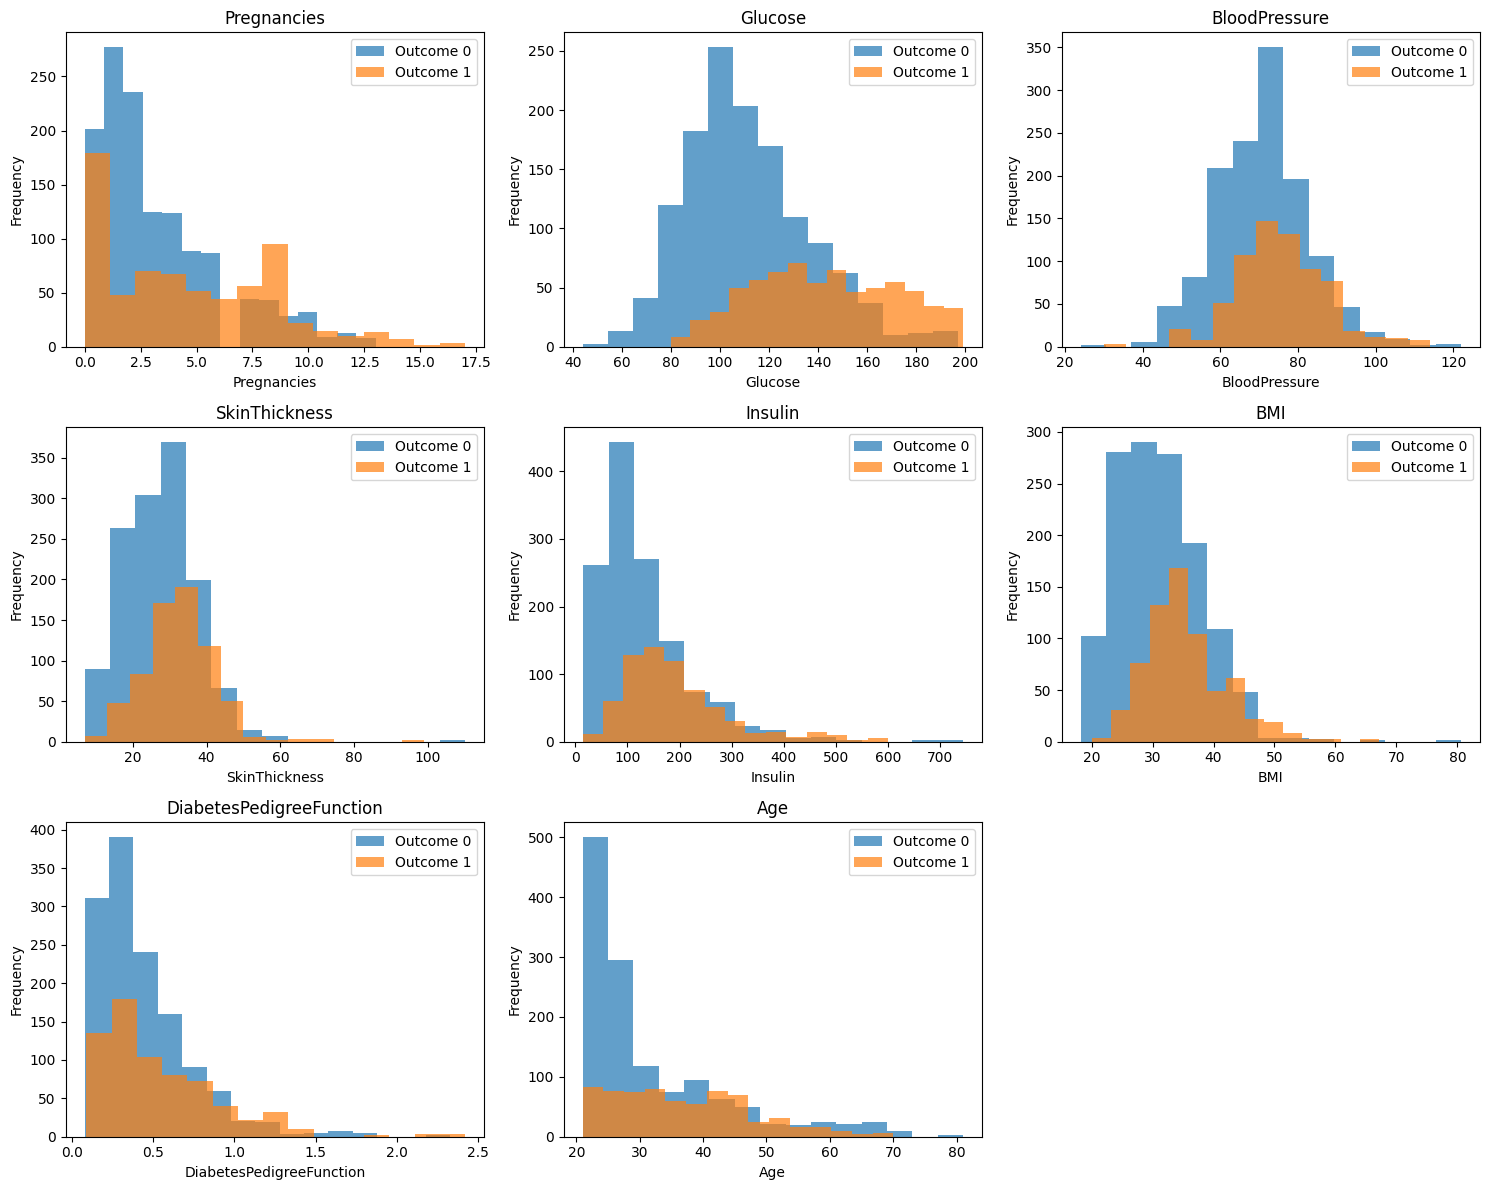

In [178]:
# Distribusi fitur terhadap target (Outcome)
features = df.columns[:-1]  # semua kecuali Outcome
plt.figure(figsize=(15, 12))
for i, col in enumerate(features):
    plt.subplot(3, 3, i+1)
    for outcome in [0, 1]:
        data = df[df['Outcome'] == outcome][col]
        plt.hist(data, alpha=0.7, label=f'Outcome {outcome}', bins=15)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend()
plt.tight_layout()
plt.show()

In [179]:
# Pisah fitur dan target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [180]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42,
)

In [181]:
y_train.value_counts(), y_test.value_counts()

(Outcome
 0    927
 1    473
 Name: count, dtype: int64,
 Outcome
 0    389
 1    211
 Name: count, dtype: int64)

## NORMALISASI

In [182]:
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

In [183]:
X_train_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.352941,0.516129,0.489796,0.198039,0.138630,0.150641,0.123826,0.133333
1,0.058824,0.483871,0.204082,0.382353,0.067123,0.277244,0.086251,0.066667
2,0.470588,0.425806,0.530612,0.247059,0.242192,0.153846,0.067891,0.616667
3,0.000000,0.541935,0.448980,0.107843,0.227397,0.197115,0.560632,0.066667
4,0.000000,0.412903,0.448980,0.117647,0.112877,0.145833,0.302733,0.183333


## BALANCING DATA - SMOTE

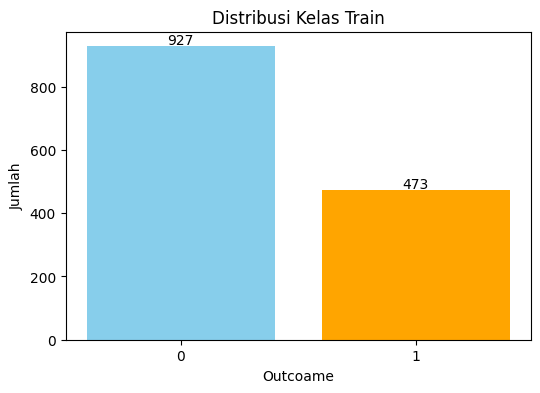

In [184]:
# Diagram distribusi kelas sebelum SMOTE
plt.figure(figsize=(6, 4))
plt.bar([0, 1], [(y_train == 0).sum(), (y_train == 1).sum()], color=['skyblue', 'orange'])
plt.title('Distribusi Kelas Train')
plt.xlabel('Outcoame')
plt.ylabel('Jumlah')
plt.xticks([0, 1])
for i, v in enumerate([(y_train == 0).sum(), (y_train == 1).sum()]):
    plt.text(i, v + 5, str(v), ha='center')
plt.show()

In [185]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

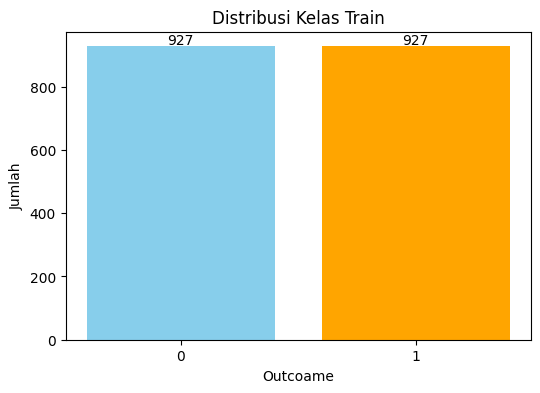

In [186]:
# Diagram distribusi kelas sebelum SMOTE
plt.figure(figsize=(6, 4))
plt.bar([0, 1], [(y_train_smote == 0).sum(), (y_train_smote == 1).sum()], color=['skyblue', 'orange'])
plt.title('Distribusi Kelas Train')
plt.xlabel('Outcoame')
plt.ylabel('Jumlah')
plt.xticks([0, 1])
for i, v in enumerate([(y_train_smote == 0).sum(), (y_train_smote == 1).sum()]):
    plt.text(i, v + 5, str(v), ha='center')
plt.show()

# MODELLING

## HYPERPARAMETER TUNING

In [187]:
jumlah_fold = 5
kfold = KFold(n_splits=jumlah_fold, shuffle=True, random_state=42)
ukuran_fold = len(X_train_smote) // jumlah_fold
sisa_fold = len(X_train_smote) % jumlah_fold

print(f"\nUkuran per fold:")
for i in range(jumlah_fold):
    if i < sisa_fold:
        ukuran = ukuran_fold + 1
    else:
        ukuran = ukuran_fold
    print(f"  Fold {i+1}: {ukuran:,} sampel")


Ukuran per fold:
  Fold 1: 371 sampel
  Fold 2: 371 sampel
  Fold 3: 371 sampel
  Fold 4: 371 sampel
  Fold 5: 370 sampel


In [188]:
# list parameter model
# Define parameter grids untuk setiap model
param_grids = {
    'SVM': {
        'C': [0.1, 1, 10, 100, 1000],
        'gamma': ['scale', 'auto'],
        'kernel': ['rbf', 'linear']
    },
    'KNN': {
        'n_neighbors': [5, 7, 9, 11, 13, 15, 17, 19],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski']
    },
    'MLP': {
        'max_iter': [100, 500, 1000],
        'hidden_layer_sizes':[(100,), (50,50), (30,20), (20,10)],
        'activation': ['relu', 'tanh', 'logistic'],
        'alpha': [0.0001, 0.001, 0.01, 0.1],
    },
    'LogReg': {
        'C': np.logspace(-4, 4, 20),
        'solver': ['liblinear', 'lbfgs'],
        'penalty': ['l1','l2']
    },

}

### LOGISTIC

In [189]:
model_lr = LogisticRegression(random_state=42)
grid_search_lr = GridSearchCV(model_lr, param_grids['LogReg'], cv=kfold, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_lr.fit(X_train_smote, y_train_smote)
print(f"LR Best Score: {grid_search_lr.best_score_:.4f}")
print(f"LR Best Params: {grid_search_lr.best_params_}")

# menampilkan hasil per fold terbaik
results_lr = pd.DataFrame(grid_search_lr.cv_results_)
best_idx = grid_search_lr.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_lr.loc[best_idx, f'split{fold}_test_score']
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_search_lr.best_score_:.4f}")
print(f"Std: {results_lr.loc[best_idx, 'std_test_score']:.4f}")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
LR Best Score: 0.7481
LR Best Params: {'C': np.float64(0.012742749857031334), 'penalty': 'l2', 'solver': 'liblinear'}
Fold 1: 0.7601
Fold 2: 0.7089
Fold 3: 0.7466
Fold 4: 0.7655
Fold 5: 0.7595
Mean: 0.7481
Std: 0.0206


### KNN

In [190]:
model_knn = KNeighborsClassifier()
grid_search_knn = GridSearchCV(model_knn, param_grids['KNN'], cv=kfold, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_knn.fit(X_train_smote, y_train_smote)
print(f"KNN Best Score: {grid_search_knn.best_score_:.4f}")
print(f"KNN Best Params: {grid_search_knn.best_params_}")

# menampilkan hasil per fold terbaik
results_knn = pd.DataFrame(grid_search_knn.cv_results_)
best_idx = grid_search_knn.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_knn.loc[best_idx, f'split{fold}_test_score']
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_search_knn.best_score_:.4f}")
print(f"Std: {results_knn.loc[best_idx, 'std_test_score']:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
KNN Best Score: 0.9445
KNN Best Params: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Fold 1: 0.9461
Fold 2: 0.9380
Fold 3: 0.9326
Fold 4: 0.9434
Fold 5: 0.9622
Mean: 0.9445
Std: 0.0100


### SVM

In [191]:
model_svm = SVC(random_state=42)
grid_search_svm = GridSearchCV(model_svm, param_grids['SVM'], cv=kfold, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_svm.fit(X_train_smote, y_train_smote)
print(f"SVM Best Score: {grid_search_svm.best_score_:.4f}")
print(f"SVM Best Params: {grid_search_svm.best_params_}")

# menampilkan hasil per fold terbaik
results_svm = pd.DataFrame(grid_search_svm.cv_results_)
best_idx = grid_search_svm.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_svm.loc[best_idx, f'split{fold}_test_score']
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_search_svm.best_score_:.4f}")
print(f"Std: {results_svm.loc[best_idx, 'std_test_score']:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
SVM Best Score: 0.9180
SVM Best Params: {'C': 1000, 'gamma': 'scale', 'kernel': 'rbf'}
Fold 1: 0.9326
Fold 2: 0.9218
Fold 3: 0.9057
Fold 4: 0.9030
Fold 5: 0.9270
Mean: 0.9180
Std: 0.0117


### MLP

In [192]:
model_mlp = MLPClassifier(random_state=42)
grid_search_mlp = GridSearchCV(model_mlp,param_grids['MLP'] , cv=kfold, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_mlp.fit(X_train_smote, y_train_smote)
print(f"MLP Best Score: {grid_search_mlp.best_score_:.4f}")
print(f"MLP Best Params: {grid_search_mlp.best_params_}")

# menampilkan hasil per fold terbaik
results_mlp = pd.DataFrame(grid_search_mlp.cv_results_)
best_idx = grid_search_mlp.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_mlp.loc[best_idx, f'split{fold}_test_score']
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_search_mlp.best_score_:.4f}")
print(f"Std: {results_mlp.loc[best_idx, 'std_test_score']:.4f}")

Fitting 5 folds for each of 144 candidates, totalling 720 fits
MLP Best Score: 0.8290
MLP Best Params: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (50, 50), 'max_iter': 1000}
Fold 1: 0.8113
Fold 2: 0.8329
Fold 3: 0.8329
Fold 4: 0.8194
Fold 5: 0.8486
Mean: 0.8290
Std: 0.0128


In [193]:
lr_final = LogisticRegression(**grid_search_lr.best_params_, random_state=42)
knn_final = KNeighborsClassifier(**grid_search_knn.best_params_)
svm_final = SVC(**grid_search_svm.best_params_, random_state=42, probability=True)
mlp_final = MLPClassifier(**grid_search_mlp.best_params_, random_state=42)

## MEMBUAT META FITUR DATA TRAINING

In [194]:
meta_pred_lr = cross_val_predict(lr_final, X_train_smote, y_train_smote, cv=kfold, method='predict_proba')
meta_pred_knn = cross_val_predict(knn_final, X_train_smote, y_train_smote, cv=kfold, method='predict_proba')
meta_pred_svm = cross_val_predict(svm_final, X_train_smote, y_train_smote, cv=kfold, method='predict_proba')
meta_pred_mlp = cross_val_predict(mlp_final, X_train_smote, y_train_smote, cv=kfold, method='predict_proba')

meta_features = np.column_stack([meta_pred_lr, meta_pred_knn, meta_pred_svm, meta_pred_mlp])
meta_features_df = pd.DataFrame(meta_features, columns=[
    'lr_prob_0', 'lr_prob_1',      # LR probabilitas kelas 0 dan 1
    'knn_prob_0', 'knn_prob_1',    # KNN probabilitas kelas 0 dan 1
    'svm_prob_0', 'svm_prob_1',    # SVM probabilitas kelas 0 dan 1
    'mlp_prob_0', 'mlp_prob_1'     # MLP probabilitas kelas 0 dan 1
])

print(f"Meta-features shape: {meta_features.shape}")
print(meta_features_df.head())

Meta-features shape: (1854, 8)
   lr_prob_0  lr_prob_1  knn_prob_0  knn_prob_1  svm_prob_0  svm_prob_1  \
0   0.485198   0.514802    0.000000    1.000000    0.259941    0.740059   
1   0.504574   0.495426    1.000000    0.000000    0.680093    0.319907   
2   0.447929   0.552071    1.000000    0.000000    0.992671    0.007329   
3   0.498156   0.501844    0.000000    1.000000    0.260200    0.739800   
4   0.520874   0.479126    0.603806    0.396194    0.575927    0.424073   

   mlp_prob_0  mlp_prob_1  
0    0.236136    0.763864  
1    0.785630    0.214370  
2    0.974301    0.025699  
3    0.829826    0.170174  
4    0.588404    0.411596  


### MEMBUAT META FEATURE DATA TESTING

In [195]:
# training base model dengan seluruh data training untuk prediksi pada data test

lr_final.fit(X_train_smote, y_train_smote)
knn_final.fit(X_train_smote, y_train_smote)
svm_final.fit(X_train_smote, y_train_smote)
mlp_final.fit(X_train_smote, y_train_smote)

# membuat meta features untuk data test
test_meta_pred_lr = lr_final.predict_proba(X_test_scaled)
test_meta_pred_knn = knn_final.predict_proba(X_test_scaled)
test_meta_pred_svm = svm_final.predict_proba(X_test_scaled)
test_meta_pred_mlp = mlp_final.predict_proba(X_test_scaled)

test_meta_features = np.column_stack([test_meta_pred_lr, test_meta_pred_knn, test_meta_pred_svm, test_meta_pred_mlp])
test_meta_features_df = pd.DataFrame(test_meta_features, columns=[
    'lr_prob_0', 'lr_prob_1',      # LR probabilitas kelas 0 dan 1
    'knn_prob_0', 'knn_prob_1',    # KNN probabilitas kelas 0 dan 1
    'svm_prob_0', 'svm_prob_1',    # SVM probabilitas kelas 0 dan 1
    'mlp_prob_0', 'mlp_prob_1'     # MLP probabilitas kelas 0 dan 1
])

print(f"Test Meta-features shape: {test_meta_features.shape}")
print(test_meta_features_df.head())

# definisikan inputan untuk meta learner
X_meta_train = meta_features_df
y_meta_train = y_train_smote

X_meta_test = test_meta_features_df
y_meta_test = y_test

print(f"X_meta_train: {X_meta_train.shape}")
print(f"y_meta_train: {y_meta_train.shape}")
print(f"X_meta_test: {X_meta_test.shape}")
print(f"y_meta_test: {y_meta_test.shape}")

Test Meta-features shape: (600, 8)
   lr_prob_0  lr_prob_1  knn_prob_0  knn_prob_1    svm_prob_0  svm_prob_1  \
0   0.442662   0.557338         0.0         1.0  1.928176e-01    0.807182   
1   0.559363   0.440637         1.0         0.0  9.919510e-01    0.008049   
2   0.400757   0.599243         0.0         1.0  9.600449e-02    0.903996   
3   0.478778   0.521222         0.0         1.0  1.929699e-01    0.807030   
4   0.458693   0.541307         0.0         1.0  9.151205e-14    1.000000   

   mlp_prob_0  mlp_prob_1  
0    0.568190    0.431810  
1    0.999434    0.000566  
2    0.230677    0.769323  
3    0.315904    0.684096  
4    0.012237    0.987763  
X_meta_train: (1854, 8)
y_meta_train: (1854,)
X_meta_test: (600, 8)
y_meta_test: (600,)


### SKENARIO 1: META-LEARNER KNN

In [196]:
### SKENARIO 1: META-LEARNER KNN
print("\n" + "="*60)
print("SKENARIO 1: META-LEARNER KNN")
print("="*60)

knn_meta = KNeighborsClassifier()
grid_search_knn_meta = GridSearchCV(knn_meta, param_grids['KNN'], cv=kfold, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_knn_meta.fit(X_meta_train, y_meta_train)

print(f"KNN Meta Best Score: {grid_search_knn_meta.best_score_:.4f}")
print(f"KNN Meta Best Params: {grid_search_knn_meta.best_params_}")

# Menampilkan hasil per fold terbaik
results_knn_meta = pd.DataFrame(grid_search_knn_meta.cv_results_)
best_idx = grid_search_knn_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_knn_meta.loc[best_idx, f'split{fold}_test_score']
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_search_knn_meta.best_score_:.4f}")
print(f"Std: {results_knn_meta.loc[best_idx, 'std_test_score']:.4f}")

# Train final model dan prediksi
knn_meta_final = KNeighborsClassifier(**grid_search_knn_meta.best_params_)
knn_meta_final.fit(X_meta_train, y_meta_train)
pred_knn_meta = knn_meta_final.predict(X_meta_test)


SKENARIO 1: META-LEARNER KNN
Fitting 5 folds for each of 48 candidates, totalling 240 fits
KNN Meta Best Score: 0.9455
KNN Meta Best Params: {'metric': 'manhattan', 'n_neighbors': 19, 'weights': 'uniform'}
Fold 1: 0.9542
Fold 2: 0.9488
Fold 3: 0.9326
Fold 4: 0.9326
Fold 5: 0.9595
Mean: 0.9455
Std: 0.0111


### SKENARIO 2: META-LEARNER SVM

In [197]:
### SKENARIO 2: META-LEARNER SVM
print("\n" + "="*60)
print("SKENARIO 2: META-LEARNER SVM")
print("="*60)

svm_meta = SVC(random_state=42)
grid_search_svm_meta = GridSearchCV(svm_meta, param_grids['SVM'], cv=kfold, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_svm_meta.fit(X_meta_train, y_meta_train)

print(f"SVM Meta Best Score: {grid_search_svm_meta.best_score_:.4f}")
print(f"SVM Meta Best Params: {grid_search_svm_meta.best_params_}")

# Menampilkan hasil per fold terbaik
results_svm_meta = pd.DataFrame(grid_search_svm_meta.cv_results_)
best_idx = grid_search_svm_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_svm_meta.loc[best_idx, f'split{fold}_test_score']
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_search_svm_meta.best_score_:.4f}")
print(f"Std: {results_svm_meta.loc[best_idx, 'std_test_score']:.4f}")

# Train final model dan prediksi
svm_meta_final = SVC(**grid_search_svm_meta.best_params_, random_state=42)
svm_meta_final.fit(X_meta_train, y_meta_train)
pred_svm_meta = svm_meta_final.predict(X_meta_test)


SKENARIO 2: META-LEARNER SVM
Fitting 5 folds for each of 20 candidates, totalling 100 fits
SVM Meta Best Score: 0.9450
SVM Meta Best Params: {'C': 1000, 'gamma': 'scale', 'kernel': 'linear'}
Fold 1: 0.9515
Fold 2: 0.9434
Fold 3: 0.9353
Fold 4: 0.9380
Fold 5: 0.9568
Mean: 0.9450
Std: 0.0081


### SKENARIO 3: META-LEARNER MLP

In [198]:
### SKENARIO 3: META-LEARNER MLP
print("\n" + "="*60)
print("SKENARIO 3: META-LEARNER MLP")
print("="*60)

mlp_meta = MLPClassifier(random_state=42)
grid_search_mlp_meta = GridSearchCV(mlp_meta, param_grids['MLP'], cv=kfold, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_mlp_meta.fit(X_meta_train, y_meta_train)

print(f"MLP Meta Best Score: {grid_search_mlp_meta.best_score_:.4f}")
print(f"MLP Meta Best Params: {grid_search_mlp_meta.best_params_}")

# Menampilkan hasil per fold terbaik
results_mlp_meta = pd.DataFrame(grid_search_mlp_meta.cv_results_)
best_idx = grid_search_mlp_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_mlp_meta.loc[best_idx, f'split{fold}_test_score']
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_search_mlp_meta.best_score_:.4f}")
print(f"Std: {results_mlp_meta.loc[best_idx, 'std_test_score']:.4f}")

# Train final model dan prediksi
mlp_meta_final = MLPClassifier(**grid_search_mlp_meta.best_params_, random_state=42)
mlp_meta_final.fit(X_meta_train, y_meta_train)
pred_mlp_meta = mlp_meta_final.predict(X_meta_test)


SKENARIO 3: META-LEARNER MLP
Fitting 5 folds for each of 144 candidates, totalling 720 fits
MLP Meta Best Score: 0.9472
MLP Meta Best Params: {'activation': 'logistic', 'alpha': 0.01, 'hidden_layer_sizes': (20, 10), 'max_iter': 500}
Fold 1: 0.9596
Fold 2: 0.9434
Fold 3: 0.9407
Fold 4: 0.9272
Fold 5: 0.9649
Mean: 0.9472
Std: 0.0136


### SKENARIO 4: META-LEARNER LOGISTIC REGRESSION

In [199]:
### SKENARIO 4: META-LEARNER LOGISTIC REGRESSION
print("\n" + "="*60)
print("SKENARIO 4: META-LEARNER LOGISTIC REGRESSION")
print("="*60)

logreg_meta = LogisticRegression(random_state=42)
grid_search_logreg_meta = GridSearchCV(logreg_meta, param_grids['LogReg'], cv=kfold, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_logreg_meta.fit(X_meta_train, y_meta_train)

print(f"LogReg Meta Best Score: {grid_search_logreg_meta.best_score_:.4f}")
print(f"LogReg Meta Best Params: {grid_search_logreg_meta.best_params_}")

# Menampilkan hasil per fold terbaik
results_logreg_meta = pd.DataFrame(grid_search_logreg_meta.cv_results_)
best_idx = grid_search_logreg_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_logreg_meta.loc[best_idx, f'split{fold}_test_score']
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_search_logreg_meta.best_score_:.4f}")
print(f"Std: {results_logreg_meta.loc[best_idx, 'std_test_score']:.4f}")

# Train final model dan prediksi
logreg_meta_final = LogisticRegression(**grid_search_logreg_meta.best_params_, random_state=42)
logreg_meta_final.fit(X_meta_train, y_meta_train)
pred_logreg_meta = logreg_meta_final.predict(X_meta_test)


SKENARIO 4: META-LEARNER LOGISTIC REGRESSION
Fitting 5 folds for each of 80 candidates, totalling 400 fits
LogReg Meta Best Score: 0.9439
LogReg Meta Best Params: {'C': np.float64(0.615848211066026), 'penalty': 'l1', 'solver': 'liblinear'}
Fold 1: 0.9542
Fold 2: 0.9380
Fold 3: 0.9380
Fold 4: 0.9326
Fold 5: 0.9568
Mean: 0.9439
Std: 0.0097


# EVALUASI DAN PERBANDINGAN PERFORMANCE

In [200]:
# Evaluasi base models pada test set
print("\n" + "="*80)
print("PERBANDINGAN PERFORMANCE: BASE MODELS VS STACKING")
print("="*80)

# Prediksi base models pada test set
pred_base_models = {
    'LogReg': lr_final.predict(X_test_scaled),
    'KNN': knn_final.predict(X_test_scaled),
    'SVM': svm_final.predict(X_test_scaled),
    'MLP': mlp_final.predict(X_test_scaled)
}

#
# Function untuk menghitung metrics
def calculate_metrics(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

# Collect all results
results_comparison = []

# Base models
print("\nBASE MODELS PERFORMANCE:")
print("-" * 50)
for model_name, predictions in pred_base_models.items():
    metrics = calculate_metrics(y_test, predictions, model_name)
    results_comparison.append(metrics)
    print(f"{model_name}:")
    print(f"  Accuracy:  {metrics['Accuracy']:.4f}")
    print(f"  Precision: {metrics['Precision']:.4f}")
    print(f"  Recall:    {metrics['Recall']:.4f}")
    print(f"  F1-Score:  {metrics['F1-Score']:.4f}")
    print()

# Stacking models
print("STACKING MODELS PERFORMANCE:")
print("-" * 50)

stacking_predictions = {
    'Stacking_KNN': pred_knn_meta,
    'Stacking_SVM': pred_svm_meta,
    'Stacking_MLP': pred_mlp_meta,
    'Stacking_LogReg': pred_logreg_meta,

}


for model_name, predictions in stacking_predictions.items():
    metrics = calculate_metrics(y_test, predictions, model_name)
    results_comparison.append(metrics)
    print(f"{model_name}:")
    print(f"  Accuracy:  {metrics['Accuracy']:.4f}")
    print(f"  Precision: {metrics['Precision']:.4f}")
    print(f"  Recall:    {metrics['Recall']:.4f}")
    print(f"  F1-Score:  {metrics['F1-Score']:.4f}")
    print()

# Create comparison DataFrame
comparison_df = pd.DataFrame(results_comparison)
print("\nRINGKASAN PERBANDINGAN:")
print("="*80)
print(comparison_df.round(4))


PERBANDINGAN PERFORMANCE: BASE MODELS VS STACKING

BASE MODELS PERFORMANCE:
--------------------------------------------------
LogReg:
  Accuracy:  0.7200
  Precision: 0.5616
  Recall:    0.9289
  F1-Score:  0.7000

KNN:
  Accuracy:  0.9433
  Precision: 0.9005
  Recall:    0.9431
  F1-Score:  0.9213

SVM:
  Accuracy:  0.9050
  Precision: 0.8407
  Recall:    0.9005
  F1-Score:  0.8696

MLP:
  Accuracy:  0.7950
  Precision: 0.6538
  Recall:    0.8863
  F1-Score:  0.7525

STACKING MODELS PERFORMANCE:
--------------------------------------------------
Stacking_KNN:
  Accuracy:  0.9567
  Precision: 0.9263
  Recall:    0.9526
  F1-Score:  0.9393

Stacking_SVM:
  Accuracy:  0.9433
  Precision: 0.9005
  Recall:    0.9431
  F1-Score:  0.9213

Stacking_MLP:
  Accuracy:  0.9600
  Precision: 0.9431
  Recall:    0.9431
  F1-Score:  0.9431

Stacking_LogReg:
  Accuracy:  0.9450
  Precision: 0.9120
  Recall:    0.9336
  F1-Score:  0.9227


RINGKASAN PERBANDINGAN:
             Model  Accuracy  Precisi

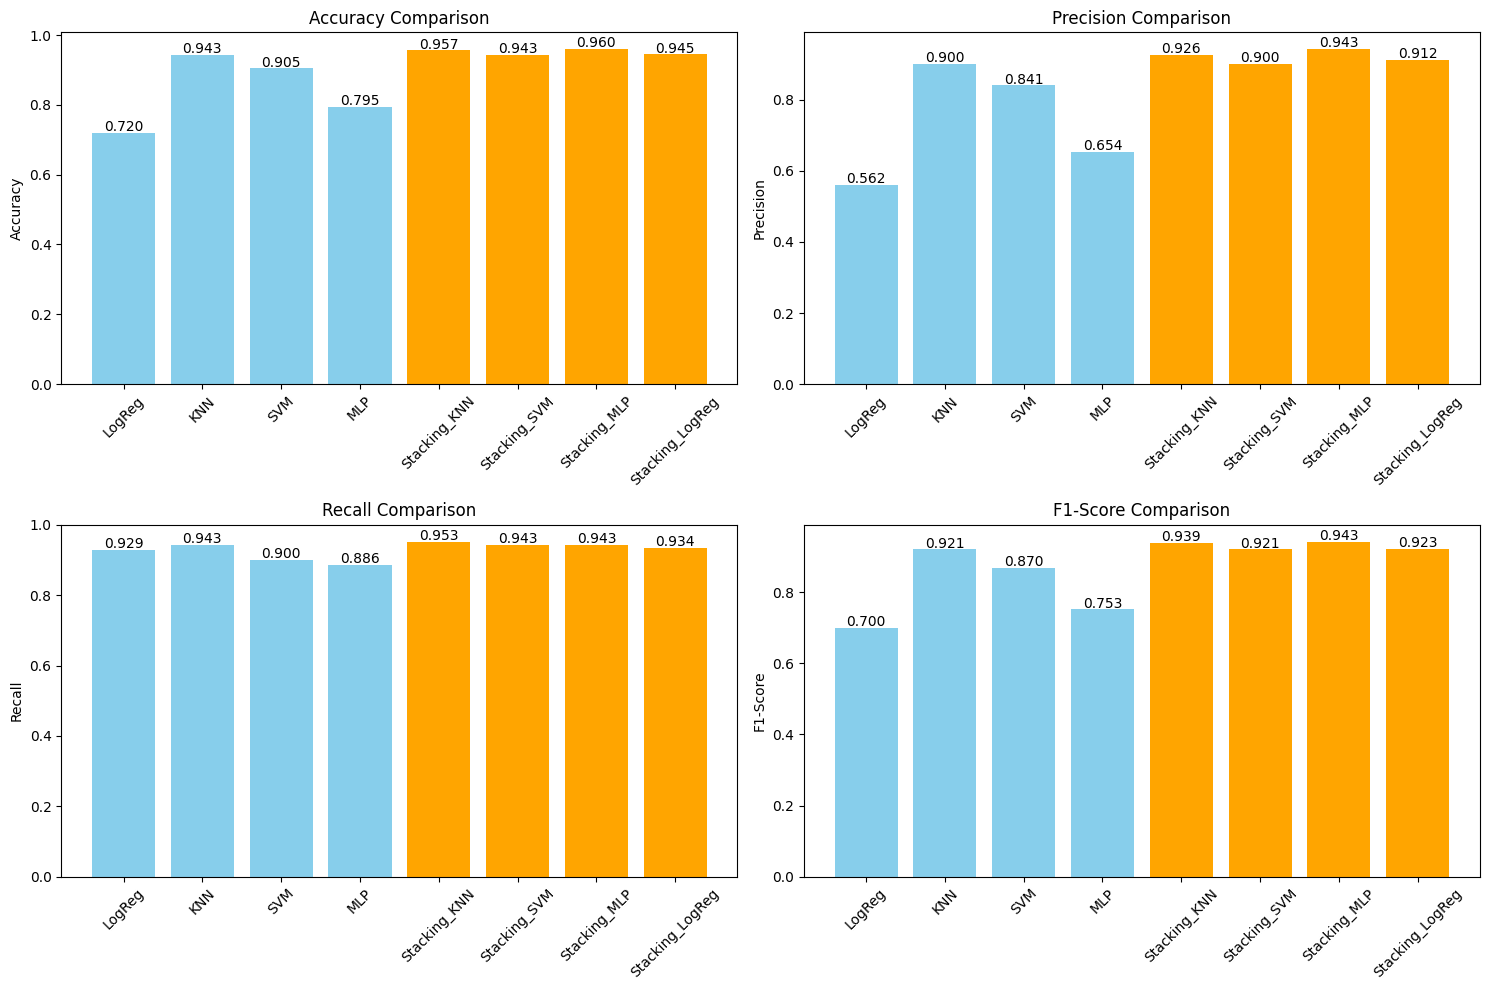

In [201]:
# Visualisasi perbandingan
plt.figure(figsize=(15, 10))

# Accuracy comparison
plt.subplot(2, 2, 1)
models = comparison_df['Model']
accuracy = comparison_df['Accuracy']
colors = ['skyblue']*4 + ['orange']*5  # Blue for base, orange for stacking
plt.bar(models, accuracy, color=colors)
plt.title('Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
for i, v in enumerate(accuracy):
    plt.text(i, v + 0.005, f'{v:.3f}', ha='center')

# Precision comparison
plt.subplot(2, 2, 2)
precision = comparison_df['Precision']
plt.bar(models, precision, color=colors)
plt.title('Precision Comparison')
plt.ylabel('Precision')
plt.xticks(rotation=45)
for i, v in enumerate(precision):
    plt.text(i, v + 0.005, f'{v:.3f}', ha='center')

# Recall comparison
plt.subplot(2, 2, 3)
recall = comparison_df['Recall']
plt.bar(models, recall, color=colors)
plt.title('Recall Comparison')
plt.ylabel('Recall')
plt.xticks(rotation=45)
for i, v in enumerate(recall):
    plt.text(i, v + 0.005, f'{v:.3f}', ha='center')

# F1-Score comparison
plt.subplot(2, 2, 4)
f1_scores = comparison_df['F1-Score']
plt.bar(models, f1_scores, color=colors)
plt.title('F1-Score Comparison')
plt.ylabel('F1-Score')
plt.xticks(rotation=45)
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.005, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

In [202]:
# Analisis Model Terbaik: Base vs Stacking
print("="*80)
print("PERBANDINGAN MODEL TERBAIK: BASE vs STACKING")
print("="*80)

# Model tunggal terbaik
best_base_model = comparison_df.loc[comparison_df['Model'].isin(['LogReg', 'KNN', 'SVM', 'MLP'])].iloc[comparison_df.loc[comparison_df['Model'].isin(['LogReg', 'KNN', 'SVM', 'MLP'])]['Accuracy'].idxmax()]

# Model stacking terbaik
best_stacking_model = comparison_df.loc[comparison_df['Model'].str.contains('Stacking')].iloc[comparison_df.loc[comparison_df['Model'].str.contains('Stacking')]['Accuracy'].idxmax()]

# Buat perbandingan langsung
comparison_best = pd.DataFrame([best_base_model, best_stacking_model])

print("\nMODEL TUNGGAL TERBAIK vs STACKING TERBAIK:")
print("-"*60)
print(comparison_best.round(4))

print("\nANALISIS PENINGKATAN:")
print("-"*40)
improvement_acc = best_stacking_model['Accuracy'] - best_base_model['Accuracy']
improvement_prec = best_stacking_model['Precision'] - best_base_model['Precision']
improvement_recall = best_stacking_model['Recall'] - best_base_model['Recall']
improvement_f1 = best_stacking_model['F1-Score'] - best_base_model['F1-Score']

print(f"Base Model Terbaik    : {best_base_model['Model']}")
print(f"  - Accuracy : {best_base_model['Accuracy']:.4f}")
print(f"  - Precision: {best_base_model['Precision']:.4f}")
print(f"  - Recall   : {best_base_model['Recall']:.4f}")
print(f"  - F1-Score : {best_base_model['F1-Score']:.4f}")

print(f"\nStacking Model Terbaik: {best_stacking_model['Model']}")
print(f"  - Accuracy : {best_stacking_model['Accuracy']:.4f}")
print(f"  - Precision: {best_stacking_model['Precision']:.4f}")
print(f"  - Recall   : {best_stacking_model['Recall']:.4f}")
print(f"  - F1-Score : {best_stacking_model['F1-Score']:.4f}")

print(f"\nPERBAIKAN YANG DICAPAI:")
print(f"  - Accuracy : +{improvement_acc:.4f} ({(improvement_acc/best_base_model['Accuracy']*100):+.2f}%)")
print(f"  - Precision: +{improvement_prec:.4f} ({(improvement_prec/best_base_model['Precision']*100):+.2f}%)")
print(f"  - Recall   : +{improvement_recall:.4f} ({(improvement_recall/best_base_model['Recall']*100):+.2f}%)")
print(f"  - F1-Score : +{improvement_f1:.4f} ({(improvement_f1/best_base_model['F1-Score']*100):+.2f}%)")

# Visualisasi perbandingan kedua model terbaik
plt.figure(figsize=(12, 8))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
base_values = [best_base_model[metric] for metric in metrics]
stacking_values = [best_stacking_model[metric] for metric in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, base_values, width, label=f'Base: {best_base_model["Model"]}', color='skyblue')
bars2 = ax.bar(x + width/2, stacking_values, width, label=f'Stacking: {best_stacking_model["Model"]}', color='orange')

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Perbandingan Model Terbaik: Base vs Stacking')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Tambahkan nilai di atas bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\nKESIMPULAN:")
print("-"*20)
print(f"✓ Stacking {best_stacking_model['Model'].replace('Stacking_', '')} memberikan performa terbaik")
print(f"✓ Peningkatan accuracy sebesar {(improvement_acc/best_base_model['Accuracy']*100):.2f}% dari model tunggal terbaik")
print(f"✓ Semua metrics mengalami peningkatan dengan pendekatan stacking")

PERBANDINGAN MODEL TERBAIK: BASE vs STACKING


IndexError: single positional indexer is out-of-bounds